# ✈️ Aircraft Engine Predictive Maintenance
## End-to-End Deep Learning Pipeline

## Made by: Yatharth Asthana
## Master's in Analytics from TISS, Mumbai

**Dataset**: NASA Turbofan Engine Degradation (CMAPSS)  
**Task**: Binary classification — predict if an engine will fail within the next **30 operational cycles**  
**Models Compared**: Stacked LSTM · Stacked GRU · BiLSTM · CNN-LSTM · Transformer · CNN-Transformer  

---

### Pipeline Overview
| Step | Description |
|------|-------------|
| 1 | Install & Import |
| 2 | Data Upload / Mount |
| 3 | Global Configuration |
| 4 | Load Data |
| 5 | Exploratory Data Analysis |
| 6 | Feature Engineering (RUL + label) |
| 7 | MinMax Normalisation |
| 8 | Sliding-Window Sequence Builder |
| 9 | Model Definitions (6 architectures) |
| 10 | Training & Evaluation Loop |
| 11 | Comparison Table & Charts |
| 12 | Threshold Tuning |
| 13 | Per-Engine Prediction Timeline |


## Install & Import

In [1]:
!pip install -q tensorflow scikit-learn seaborn

import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (confusion_matrix, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              classification_report)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, LSTM, GRU, SimpleRNN,
    Conv1D, MaxPooling1D, Flatten, GlobalAveragePooling1D,
    MultiHeadAttention, LayerNormalization, Add, Input,
    Bidirectional, BatchNormalization
)
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint,
                                         ReduceLROnPlateau)
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings("ignore")
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data Upload


In [2]:
TRAIN_PATH = 'PM_train.csv'
TEST_PATH  = 'PM_test.csv'
TRUTH_PATH = 'PM_truth.csv'

print("Data paths configured.")


Data paths configured.


## Global Configuration


In [3]:
# ── Sequence & label ──────────────────────────────────────
SEQUENCE_LENGTH   = 50     # look-back window (time steps)
FAILURE_WINDOW    = 30     # label an engine as 1 if RUL <= this value

# ── Training ──────────────────────────────────────────────
BATCH_SIZE        = 128
MAX_EPOCHS        = 150
PATIENCE          = 15     # early-stopping patience
DROPOUT_RATE      = 0.3
LEARNING_RATE     = 1e-3

# ── Feature selection ─────────────────────────────────────
ZERO_VAR_THRESHOLD = 1e-4  # sensors with std < threshold are dropped

# ── I/O ───────────────────────────────────────────────────
MODEL_DIR = 'saved_models'
os.makedirs(MODEL_DIR, exist_ok=True)
print("Configuration set.")


Configuration set.


## Loading the Data

In [5]:
col_names = (['id', 'cycle', 'setting1', 'setting2', 'setting3'] +
             [f's{i}' for i in range(1, 22)])

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)
truth_df = pd.read_csv(TRUTH_PATH)

# Assigning column names if the files have no header
if list(train_df.columns) == list(range(len(train_df.columns))):
    train_df.columns = col_names
    test_df.columns  = col_names

# Standardising truth columns
truth_df.columns = (['id', 'RUL_true'] if truth_df.shape[1] == 2
                    else ['RUL_true'])

train_df.sort_values(['id', 'cycle'], inplace=True)
test_df.sort_values( ['id', 'cycle'], inplace=True)
train_df.reset_index(drop=True, inplace=True)
test_df.reset_index( drop=True, inplace=True)

print(f"Train  : {train_df.shape}  | Engines: {train_df['id'].nunique()}")
print(f"Test   : {test_df.shape}  | Engines: {test_df['id'].nunique()}")
print(f"Truth  : {truth_df.shape}")
train_df.head(3)


Train  : (20631, 26)  | Engines: 100
Test   : (13096, 26)  | Engines: 100
Truth  : (100, 2)


,id,cycle,setting1,setting2,setting3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442


## Exploratory Data Analysis

### To Identify and drop low-variance (non-informative) sensors  
Sensors with near-zero standard deviation carry no degradation signal and are removed.

### Plotting sensor degradation trends  
### Correlation heat-map


In [6]:
sensor_cols = [f's{i}' for i in range(1, 22)]
stds = train_df[sensor_cols].std()
low_var      = stds[stds < ZERO_VAR_THRESHOLD].index.tolist()
useful_sensors = [c for c in sensor_cols if c not in low_var]
print(f"Dropped (low-variance) : {low_var}")
print(f"Kept ({len(useful_sensors)})             : {useful_sensors}")


Dropped (low-variance) : ['s1', 's5', 's10', 's16', 's18', 's19']
Kept (15)             : ['s2', 's3', 's4', 's6', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']


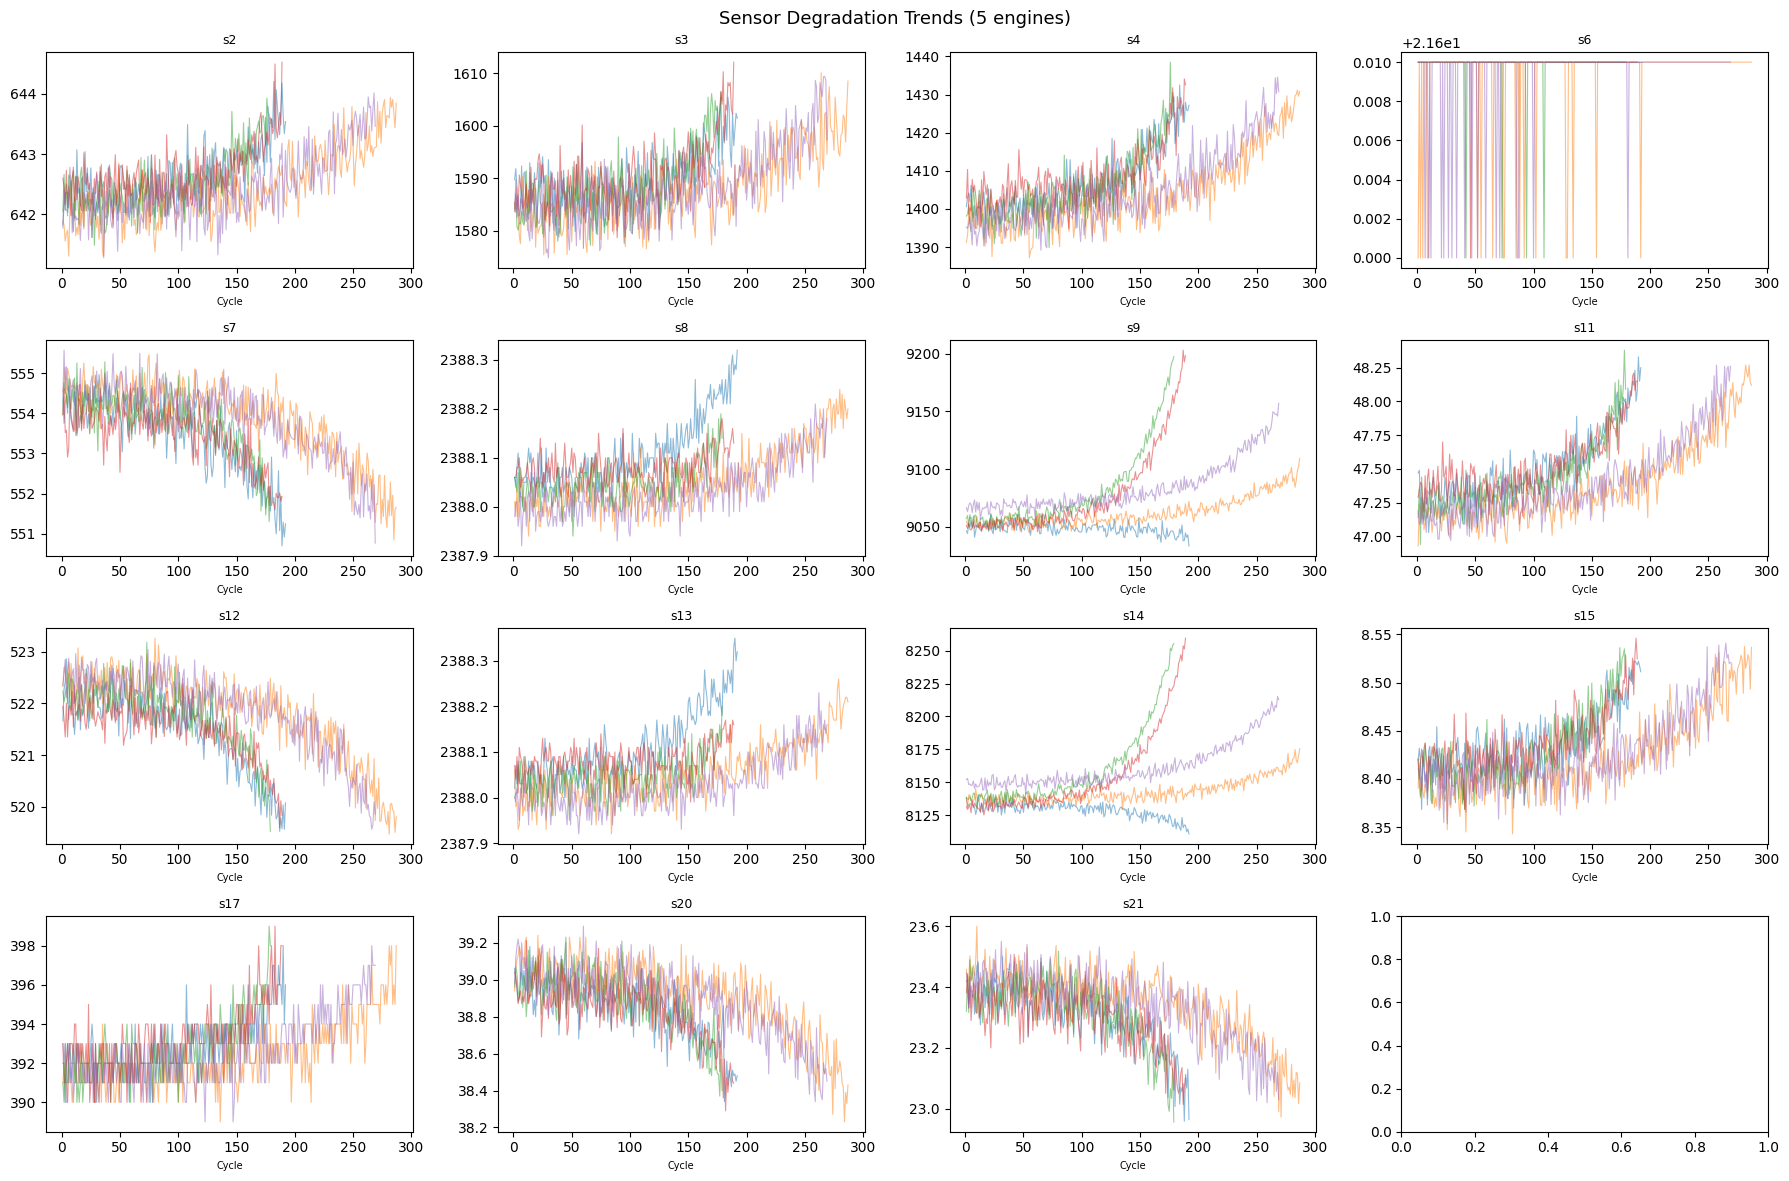

In [7]:
# ── Sensor degradation trends (5 sample engines) ─────────
fig, axes = plt.subplots(4, 4, figsize=(18, 12))
sample_ids = train_df['id'].unique()[:5]
for ax, col in zip(axes.flat, useful_sensors[:16]):
    for eid in sample_ids:
        sub = train_df[train_df['id'] == eid]
        ax.plot(sub['cycle'], sub[col], alpha=0.5, linewidth=0.8)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('Cycle', fontsize=7)
plt.suptitle('Sensor Degradation Trends (5 engines)', fontsize=13)
plt.tight_layout()
plt.show()


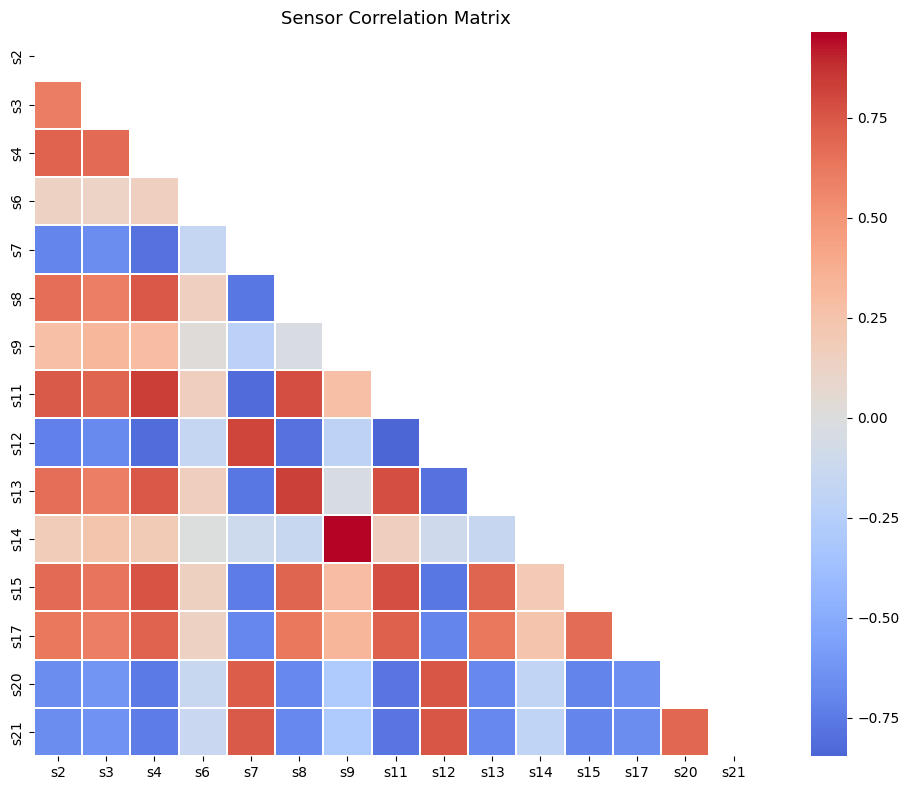

In [8]:
# Correlation heat-map
plt.figure(figsize=(11, 8))
corr = train_df[useful_sensors].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            linewidths=0.3, square=True)
plt.title('Sensor Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()


## Feature Engineering

**Remaining Useful Life (RUL)** = max_cycle − current_cycle  
**Binary label** = 1 if RUL ≤ `FAILURE_WINDOW` (30 cycles)


In [9]:
# Training RUL & label
rul = (train_df.groupby('id')['cycle']
               .max().reset_index()
               .rename(columns={'cycle': 'max_cycle'}))
train_df = train_df.merge(rul, on='id', how='left')
train_df['RUL']   = train_df['max_cycle'] - train_df['cycle']
train_df['label'] = (train_df['RUL'] <= FAILURE_WINDOW).astype(int)
train_df.drop('max_cycle', axis=1, inplace=True)

# Testing RUL & label (using ground truth)
test_rul = (test_df.groupby('id')['cycle']
                   .max().reset_index()
                   .rename(columns={'cycle': 'last_cycle'}))
truth_df = truth_df.reset_index(drop=True)
if 'id' not in truth_df.columns:
    truth_df.insert(0, 'id', range(1, len(truth_df) + 1))
truth_df = truth_df.merge(test_rul, on='id', how='left')
truth_df['total_cycles'] = truth_df['last_cycle'] + truth_df['RUL_true']

test_df = test_df.merge(truth_df[['id', 'total_cycles']], on='id', how='left')
test_df['RUL']   = test_df['total_cycles'] - test_df['cycle']
test_df['label'] = (test_df['RUL'] <= FAILURE_WINDOW).astype(int)
test_df.drop('total_cycles', axis=1, inplace=True)

print("Train class balance:")
print(train_df['label'].value_counts(normalize=True)
      .rename({0: 'Normal (0)', 1: 'Near-Failure (1)'}).round(3))
print("\nTest class balance:")
print(test_df['label'].value_counts(normalize=True)
      .rename({0: 'Normal (0)', 1: 'Near-Failure (1)'}).round(3))


Train class balance:
label
Normal (0)          0.85
Near-Failure (1)    0.15
Name: proportion, dtype: float64

Test class balance:
label
Normal (0)          0.975
Near-Failure (1)    0.025
Name: proportion, dtype: float64


## Normalisation  (MinMax 0–1)

In [10]:
setting_cols = ['setting1', 'setting2', 'setting3']
feature_cols = setting_cols + useful_sensors
norm_cols    = feature_cols + ['cycle']          # also normalise cycle

scaler = MinMaxScaler()
train_df[norm_cols] = scaler.fit_transform(train_df[norm_cols])
test_df[norm_cols]  = scaler.transform(test_df[norm_cols])

sequence_cols = norm_cols
print(f"Input features: {len(sequence_cols)}  →  {sequence_cols}")


Input features: 19  →  ['setting1', 'setting2', 'setting3', 's2', 's3', 's4', 's6', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21', 'cycle']


## Sliding-Window Sequence Builder

Each sample is a 3-D tensor of shape **(seq_len, n_features)** representing  
the last `SEQUENCE_LENGTH` cycles of one engine.  
The label is taken from the **last time step** of each window.


In [11]:
def build_sequences(df, seq_len, feat_cols, label_col='label'):
    """
    Slide a window of `seq_len` over every engine's history.
    Returns
    -------
    X : ndarray (N, seq_len, n_features) float32
    y : ndarray (N,)                     int32
    """
    X_list, y_list = [], []
    for eid in df['id'].unique():
        sub    = df[df['id'] == eid].sort_values('cycle')
        data   = sub[feat_cols].values.astype(np.float32)
        labels = sub[label_col].values.astype(np.int32)
        for i in range(len(data) - seq_len + 1):
            X_list.append(data[i: i + seq_len])
            y_list.append(labels[i + seq_len - 1])
    return np.array(X_list), np.array(y_list)


print("Building training sequences …")
X_train, y_train = build_sequences(train_df, SEQUENCE_LENGTH, sequence_cols)
print("Building test sequences …")
X_test,  y_test  = build_sequences(test_df,  SEQUENCE_LENGTH, sequence_cols)

print(f"\nX_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}    y_test  : {y_test.shape}")
print(f"Train positive rate: {y_train.mean():.3f}")
print(f"Test  positive rate: {y_test.mean():.3f}")

INPUT_SHAPE = (SEQUENCE_LENGTH, X_train.shape[2])

# Class weights to counter imbalance
neg, pos = np.bincount(y_train)
class_weight = {0: 1.0, 1: neg / pos}
print(f"\nClass weights → 0: {class_weight[0]:.2f}  1: {class_weight[1]:.2f}")


Building training sequences …
Building test sequences …

X_train : (15731, 50, 19)   y_train : (15731,)
X_test  : (8255, 50, 19)    y_test  : (8255,)
Train positive rate: 0.197
Test  positive rate: 0.040

Class weights → 0: 1.00  1: 4.07


## Training Callbacks

- **EarlyStopping** – stops when `val_loss` stagnates for `PATIENCE` epochs  
- **ModelCheckpoint** – saves the best weights automatically  
- **ReduceLROnPlateau** – halves the learning rate if val_loss plateaus for 7 epochs


In [12]:
def get_callbacks(name):
    return [
        EarlyStopping(monitor='val_loss', patience=PATIENCE,
                      restore_best_weights=True, verbose=0),
        ModelCheckpoint(f'{MODEL_DIR}/{name}.keras',
                        monitor='val_loss', save_best_only=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=7, min_lr=1e-6, verbose=0),
    ]
print("Callbacks defined.")


Callbacks defined.


## Model Architectures

Six architectures are defined:

| # | Model | Key Idea |
|---|-------|----------|
| 1 | **Stacked LSTM** | 3-layer LSTM with BatchNorm & Dropout |
| 2 | **Stacked GRU** | GRU equivalent – fewer parameters |
| 3 | **Bidirectional LSTM** | Reads sequence forwards & backwards |
| 4 | **CNN-LSTM** | Convolutions extract local patterns → LSTM models temporal dependency |
| 5 | **Transformer** | Self-attention with positional mixing |
| 6 | **CNN-Transformer** | Conv feature extractor + Transformer encoder (hybrid) |


In [13]:
#   Stacked LSTM

def build_stacked_lstm(input_shape, dropout=DROPOUT_RATE, lr=LEARNING_RATE):
    model = Sequential([
        LSTM(128, input_shape=input_shape, return_sequences=True),
        BatchNormalization(),
        Dropout(dropout),
        LSTM(64, return_sequences=True),
        BatchNormalization(),
        Dropout(dropout),
        LSTM(32, return_sequences=False),
        Dropout(dropout),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid'),
    ], name='Stacked_LSTM')
    model.compile(optimizer=Adam(lr), loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# ══════════════════════════════════════════════════════════
#   Stacked GRU
# ══════════════════════════════════════════════════════════
def build_stacked_gru(input_shape, dropout=DROPOUT_RATE, lr=LEARNING_RATE):
    model = Sequential([
        GRU(128, input_shape=input_shape, return_sequences=True),
        BatchNormalization(),
        Dropout(dropout),
        GRU(64, return_sequences=True),
        BatchNormalization(),
        Dropout(dropout),
        GRU(32, return_sequences=False),
        Dropout(dropout),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid'),
    ], name='Stacked_GRU')
    model.compile(optimizer=Adam(lr), loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# ══════════════════════════════════════════════════════════
#   Bidirectional LSTM
# ══════════════════════════════════════════════════════════
def build_bilstm(input_shape, dropout=DROPOUT_RATE, lr=LEARNING_RATE):
    model = Sequential([
        Bidirectional(LSTM(64, return_sequences=True), input_shape=input_shape),
        BatchNormalization(),
        Dropout(dropout),
        Bidirectional(LSTM(32, return_sequences=False)),
        Dropout(dropout),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid'),
    ], name='BiLSTM')
    model.compile(optimizer=Adam(lr), loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# ══════════════════════════════════════════════════════════
#   CNN + LSTM
# ══════════════════════════════════════════════════════════
def build_cnn_lstm(input_shape, dropout=DROPOUT_RATE, lr=LEARNING_RATE):
    model = Sequential([
        Conv1D(64, kernel_size=3, activation='relu',
               padding='same', input_shape=input_shape),
        BatchNormalization(),
        Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),
        Dropout(dropout),
        LSTM(64, return_sequences=False),
        Dropout(dropout),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid'),
    ], name='CNN_LSTM')
    model.compile(optimizer=Adam(lr), loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# ══════════════════════════════════════════════════════════
#   Transformer Encoder
# ══════════════════════════════════════════════════════════
def transformer_encoder_block(x, num_heads, ff_dim, dropout):
    attn = MultiHeadAttention(num_heads=num_heads, key_dim=x.shape[-1])(x, x)
    attn = Dropout(dropout)(attn)
    x    = LayerNormalization(epsilon=1e-6)(Add()([x, attn]))
    ff   = Dense(ff_dim, activation='relu')(x)
    ff   = Dense(x.shape[-1])(ff)
    ff   = Dropout(dropout)(ff)
    x    = LayerNormalization(epsilon=1e-6)(Add()([x, ff]))
    return x

def build_transformer(input_shape, num_heads=4, ff_dim=128,
                      n_blocks=2, dropout=DROPOUT_RATE, lr=LEARNING_RATE):
    inp = Input(shape=input_shape)
    x   = Dense(64)(inp)                          # project to model dim
    for _ in range(n_blocks):
        x = transformer_encoder_block(x, num_heads, ff_dim, dropout)
    x   = GlobalAveragePooling1D()(x)
    x   = Dropout(dropout)(x)
    x   = Dense(32, activation='relu')(x)
    out = Dense(1, activation='sigmoid')(x)
    model = Model(inp, out, name='Transformer')
    model.compile(optimizer=Adam(lr), loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# ══════════════════════════════════════════════════════════
#   CNN + Transformer (Hybrid)
# ══════════════════════════════════════════════════════════
def build_cnn_transformer(input_shape, num_heads=4, ff_dim=128,
                          dropout=DROPOUT_RATE, lr=LEARNING_RATE):
    inp = Input(shape=input_shape)
    x   = Conv1D(64, 3, activation='relu', padding='same')(inp)
    x   = BatchNormalization()(x)
    x   = Conv1D(64, 3, activation='relu', padding='same')(x)
    x   = transformer_encoder_block(x, num_heads, ff_dim, dropout)
    x   = GlobalAveragePooling1D()(x)
    x   = Dropout(dropout)(x)
    x   = Dense(32, activation='relu')(x)
    out = Dense(1, activation='sigmoid')(x)
    model = Model(inp, out, name='CNN_Transformer')
    model.compile(optimizer=Adam(lr), loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

print("All 6 model builders defined")


All 6 model builders defined


## Evaluation Helper

In [14]:
def evaluate(model, X, y, threshold=0.5):
    """Returns a dict of metrics plus raw predictions."""
    y_prob = model.predict(X, verbose=0).ravel()
    y_pred = (y_prob >= threshold).astype(int)
    cm     = confusion_matrix(y, y_pred)
    p  = precision_score(y, y_pred, zero_division=0)
    r  = recall_score(y, y_pred, zero_division=0)
    f1 = f1_score(y, y_pred, zero_division=0)
    try:
        auc = roc_auc_score(y, y_prob)
    except Exception:
        auc = float('nan')
    acc = (y_pred == y).mean()
    return dict(accuracy=acc, precision=p, recall=r,
                f1=f1, auc=auc, cm=cm, y_prob=y_prob, y_pred=y_pred)


def train_and_evaluate(name, build_fn, X_tr, y_tr, X_te, y_te,
                       class_weight=None):
    print(f"\n{'='*65}")
    print(f"  Training: {name}")
    print(f"{'='*65}")
    model = build_fn(INPUT_SHAPE)
    model.summary(line_length=70)

    t0 = time.time()
    history = model.fit(
        X_tr, y_tr,
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,
        class_weight=class_weight,
        callbacks=get_callbacks(name),
        verbose=1,
    )
    elapsed = time.time() - t0
    print(f"\nTraining time : {elapsed:.1f}s  |  Epochs: {len(history.history['loss'])}")

    metrics = evaluate(model, X_te, y_te)
    print("\n── Test Results ──")
    for k, v in metrics.items():
        if k not in ('cm', 'y_prob', 'y_pred'):
            print(f"  {k:<12}: {v:.4f}")
    print(f"  Confusion matrix:\n{metrics['cm']}")
    return model, history, metrics, elapsed

print("Evaluation helpers defined")


Evaluation helpers defined


## Training All Models


In [15]:
MODELS = {
    'Stacked_LSTM'    : build_stacked_lstm,
    'Stacked_GRU'     : build_stacked_gru,
    'BiLSTM'          : build_bilstm,
    'CNN_LSTM'        : build_cnn_lstm,
    'Transformer'     : build_transformer,
    'CNN_Transformer' : build_cnn_transformer,
}

results     = {}
histories   = {}
train_times = {}

for name, fn in MODELS.items():
    model, hist, metrics, t = train_and_evaluate(
        name, fn, X_train, y_train, X_test, y_test,
        class_weight=class_weight)
    results[name]     = metrics
    histories[name]   = hist
    train_times[name] = t

print("\n  All models trained.")



  Training: Stacked_LSTM


Model: "Stacked_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Layer (type)                 ┃ Output Shape          ┃     Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ lstm (LSTM)                  │ (None, 50, 128)       │      75,776 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ batch_normalization          │ (None, 50, 128)       │         512 │
│ (BatchNormalization)         │                       │             │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dropout (Dropout)            │ (None, 50, 128)       │           0 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ lstm_1 (LSTM)                │ (None, 50, 64)        │      49,408 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ batch_normalization_1        │ (None, 50, 64)        │         256 │
│ (BatchNormalization)         │                       │             │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dropout_1 (Dropout)          │ (None, 50, 64)        │           0 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ lstm_2 (LSTM)                │ (None, 32)            │      12,416 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dropout_2 (Dropout)          │ (None, 32)            │           0 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dense (Dense)                │ (None, 16)            │         528 │
├──────────────────────────────┼───────────────────────┼─────────────┤
│ dense_1 (Dense)              │ (None, 1)             │          17 │
└──────────────────────────────┴───────────────────────┴─────────────┘

 Total params: 138,913 (542.63 KB)

 Trainable params: 138,529 (541.13 KB)

...

┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)       ┃ Output Shape    ┃  Param # ┃ Connected to     ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ input_layer_5      │ (None, 50, 19)  │        0 │ -                │
│ (InputLayer)       │                 │          │                  │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ conv1d_2 (Conv1D)  │ (None, 50, 64)  │    3,712 │ input_layer_5[0… │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ batch_normalizati… │ (None, 50, 64)  │      256 │ conv1d_2[0][0]   │
│ (BatchNormalizati… │                 │          │                  │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ conv1d_3 (Conv1D)  │ (None, 50, 64)  │   12,352 │ batch_normaliza… │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ multi_head_attent… │ (None, 50, 64)  │   66,368 │ conv1d_3[0][0],  │
│ (MultiHeadAttenti… │                 │          │ conv1d_3[0][0]   │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ dropout_18         │ (None, 50, 64)  │        0 │ multi_head_atte… │
│ (Dropout)          │                 │          │                  │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ add_4 (Add)        │ (None, 50, 64)  │        0 │ conv1d_3[0][0],  │
│                    │                 │          │ dropout_18[0][0] │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ layer_normalizati… │ (None, 50, 64)  │      128 │ add_4[0][0]      │
│ (LayerNormalizati… │                 │          │                  │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ dense_15 (Dense)   │ (None, 50, 128) │    8,320 │ layer_normaliza… │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ dense_16 (Dense)   │ (None, 50, 64)  │    8,256 │ dense_15[0][0]   │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ dropout_19         │ (None, 50, 64)  │        0 │ dense_16[0][0]   │
│ (Dropout)          │                 │          │                  │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ add_5 (Add)        │ (None, 50, 64)  │        0 │ layer_normaliza… │
│                    │                 │          │ dropout_19[0][0] │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ layer_normalizati… │ (None, 50, 64)  │      128 │ add_5[0][0]      │
│ (LayerNormalizati… │                 │          │                  │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ global_average_po… │ (None, 64)      │        0 │ layer_normaliza… │
│ (GlobalAveragePoo… │                 │          │                  │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ dropout_20         │ (None, 64)      │        0 │ global_average_… │
│ (Dropout)          │                 │          │                  │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ dense_17 (Dense)   │ (None, 32)      │    2,080 │ dropout_20[0][0] │
├────────────────────┼─────────────────┼──────────┼──────────────────┤
│ dense_18 (Dense)   │ (None, 1)       │       33 │ dense_17[0][0]   │
└────────────────────┴─────────────────┴──────────┴──────────────────┘

 Total params: 101,633 (397.00 KB)

 Trainable params: 101,505 (396.50 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/150
111/111 ━━━━━━━━━━━━━━━━━━━━ 20s 85ms/step - accuracy: 0.9068 - loss: 0.3284 - val_accuracy: 0.8844 - val_loss: 0.3002 - learning_rate: 0.0010
Epoch 2/150
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9530 - loss: 0.1716 - val_accuracy: 0.8901 - val_loss: 0.3412 - learning_rate: 0.0010
Epoch 3/150
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9665 - loss: 0.1258 - val_accuracy: 0.9562 - val_loss: 0.1168 - learning_rate: 0.0010
Epoch 4/150
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9675 - loss: 0.1165 - val_accuracy: 0.9403 - val_loss: 0.1087 - learning_rate: 0.0010
Epoch 5/150
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9713 - loss: 0.1068 - val_accuracy: 0.9733 - val_loss: 0.0624 - learning_rate: 0.0010
Epoch 6/150
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9735 - loss: 0.0999 - val_accuracy: 0.9759 - val_loss: 0.0615 - learning_rate: 0.0010
Epoch 7/150
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9734 - loss: 

## 13 · Model Comparison Table

In [16]:
summary = []
for name, m in results.items():
    summary.append({
        'Model'           : name,
        'Accuracy'        : round(m['accuracy'],  4),
        'Precision'       : round(m['precision'], 4),
        'Recall'          : round(m['recall'],    4),
        'F1-Score'        : round(m['f1'],        4),
        'ROC-AUC'         : round(m['auc'],       4),
        'Train Time (s)'  : round(train_times[name], 1),
    })

summary_df = pd.DataFrame(summary).set_index('Model')

# Here, I am Highlighting best in each numeric column
numeric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
styled = summary_df.style.highlight_max(
    subset=numeric_cols, color='lightgreen', axis=0
).highlight_min(
    subset=['Train Time (s)'], color='lightyellow', axis=0
).format({c: '{:.4f}' for c in numeric_cols})

print("\n" + "="*70)
print("  MODEL COMPARISON")
print("="*70)
print(summary_df.to_string())
print()

best_f1 = summary_df['F1-Score'].idxmax()
best_auc = summary_df['ROC-AUC'].idxmax()
print(f"Best by F1-Score : {best_f1}")
print(f"Best by ROC-AUC  : {best_auc}")

styled



  MODEL COMPARISON
                 Accuracy  Precision  Recall  F1-Score  ROC-AUC  Train Time (s)
Model                                                                          
Stacked_LSTM       0.9892     0.8329  0.9157    0.8723   0.9980           109.9
Stacked_GRU        0.9873     0.7789  0.9548    0.8579   0.9983            49.7
BiLSTM             0.9891     0.8903  0.8313    0.8598   0.9972            78.8
CNN_LSTM           0.9890     0.8473  0.8855    0.8660   0.9970            34.4
Transformer        0.9849     0.7482  0.9398    0.8331   0.9976            67.9
CNN_Transformer    0.9868     0.7648  0.9699    0.8552   0.9981            40.2

Best by F1-Score : Stacked_LSTM
Best by ROC-AUC  : Stacked_GRU


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Train Time (s)
Model,,,,,,
Stacked_LSTM,0.9892,0.8329,0.9157,0.8723,0.9980,109.900000
Stacked_GRU,0.9873,0.7789,0.9548,0.8579,0.9983,49.700000
BiLSTM,0.9891,0.8903,0.8313,0.8598,0.9972,78.800000
CNN_LSTM,0.9890,0.8473,0.8855,0.8660,0.9970,34.400000
Transformer,0.9849,0.7482,0.9398,0.8331,0.9976,67.900000
CNN_Transformer,0.9868,0.7648,0.9699,0.8552,0.9981,40.200000


## Training Curves

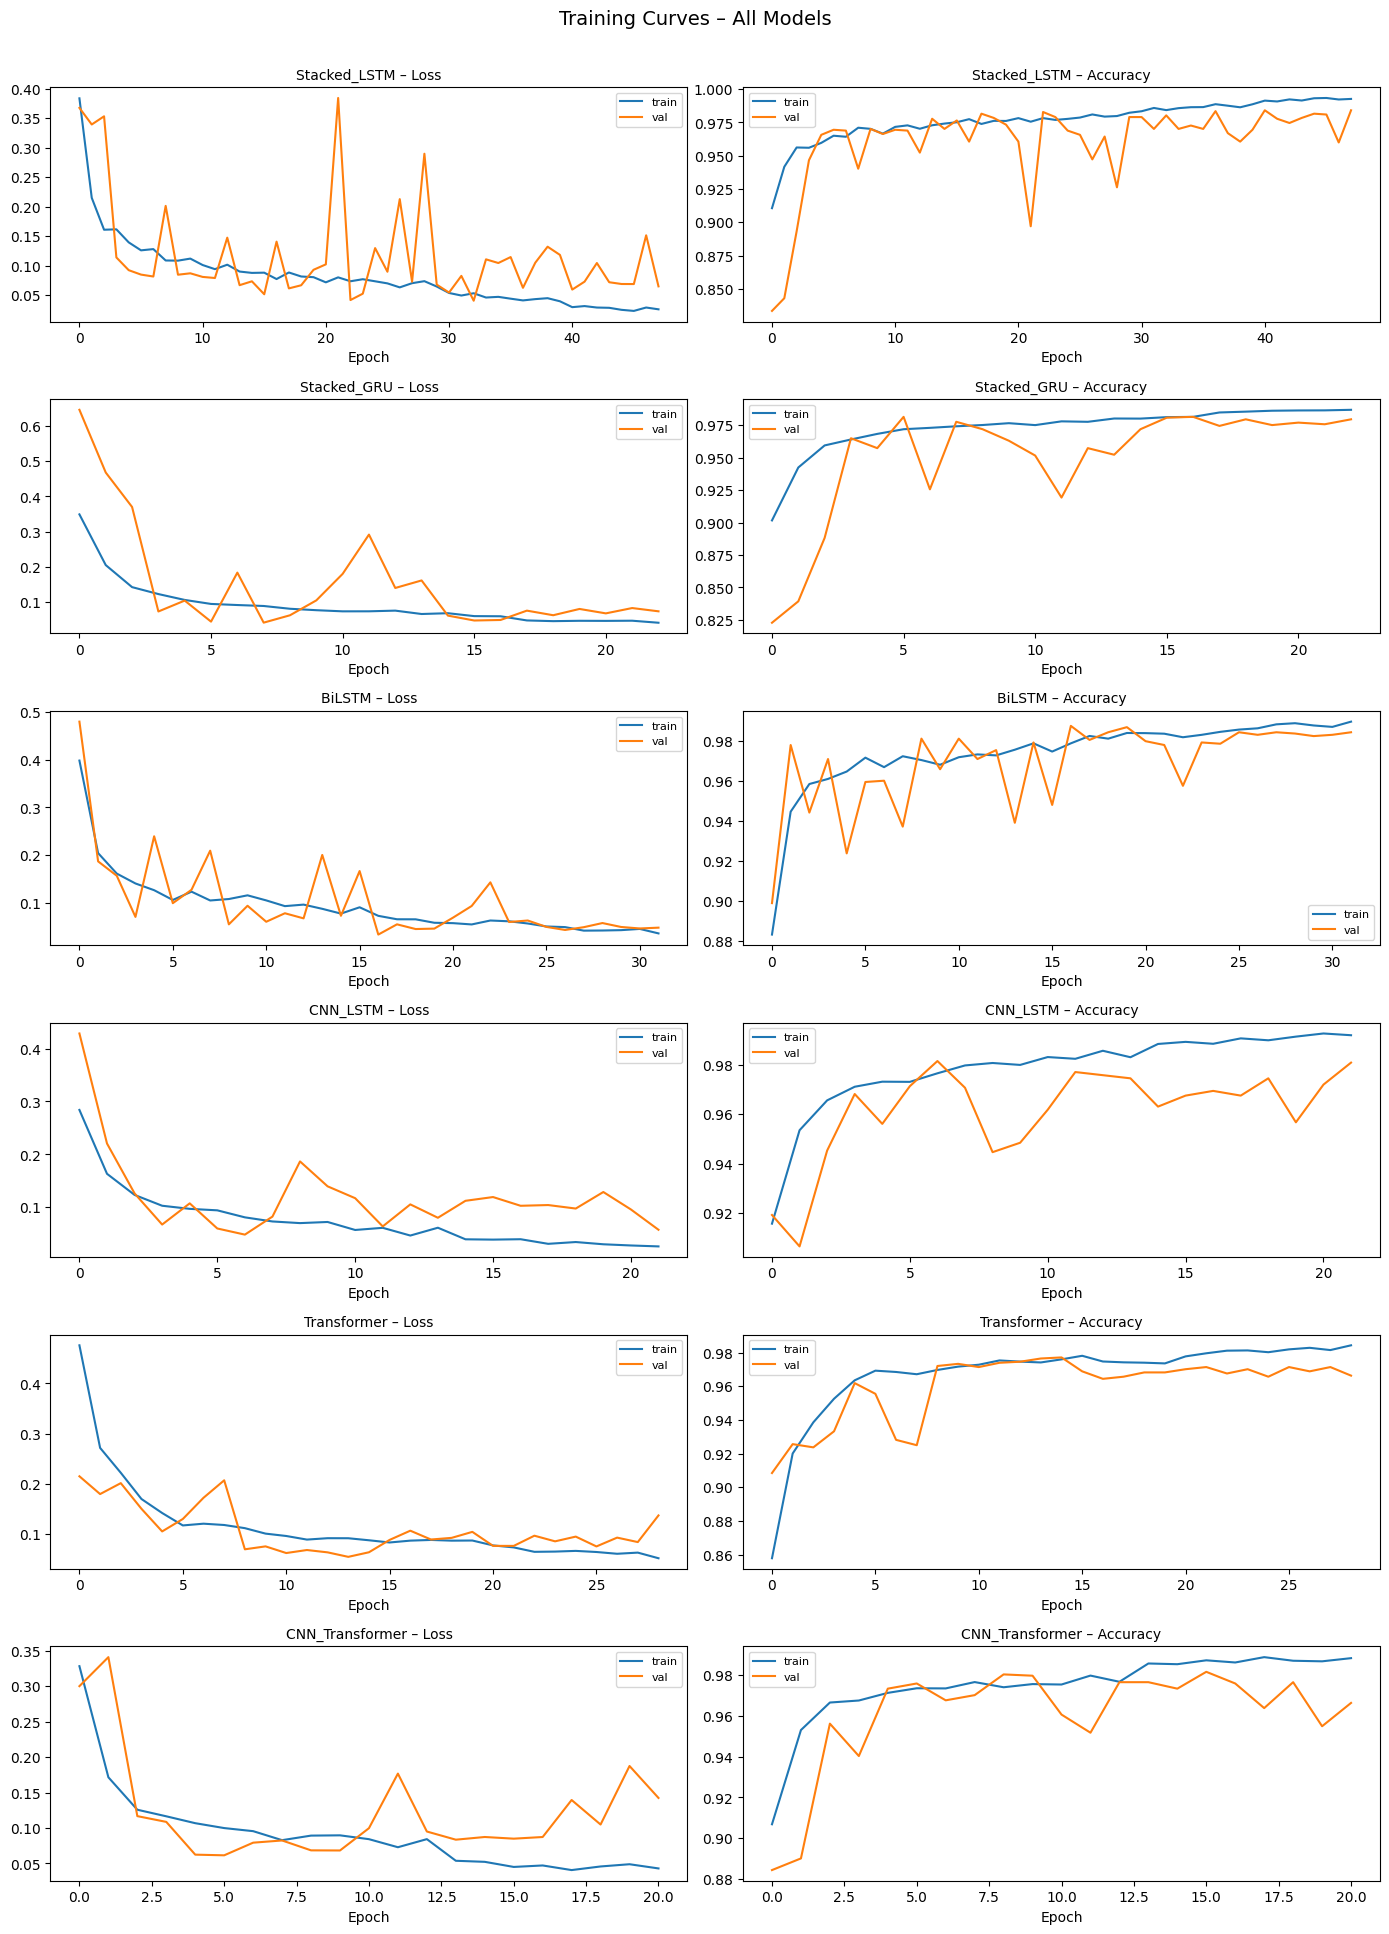

In [17]:
fig, axes = plt.subplots(len(MODELS), 2, figsize=(14, 3.2 * len(MODELS)))
for ax_row, (name, hist) in zip(axes, histories.items()):
    ax_row[0].plot(hist.history['loss'],     label='train', lw=1.5)
    ax_row[0].plot(hist.history['val_loss'], label='val',   lw=1.5)
    ax_row[0].set_title(f'{name} – Loss', fontsize=10)
    ax_row[0].legend(fontsize=8); ax_row[0].set_xlabel('Epoch')

    ax_row[1].plot(hist.history['accuracy'],     label='train', lw=1.5)
    ax_row[1].plot(hist.history['val_accuracy'], label='val',   lw=1.5)
    ax_row[1].set_title(f'{name} – Accuracy', fontsize=10)
    ax_row[1].legend(fontsize=8); ax_row[1].set_xlabel('Epoch')

plt.suptitle('Training Curves – All Models', fontsize=14, y=1.005)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()


## Confusion Matrices

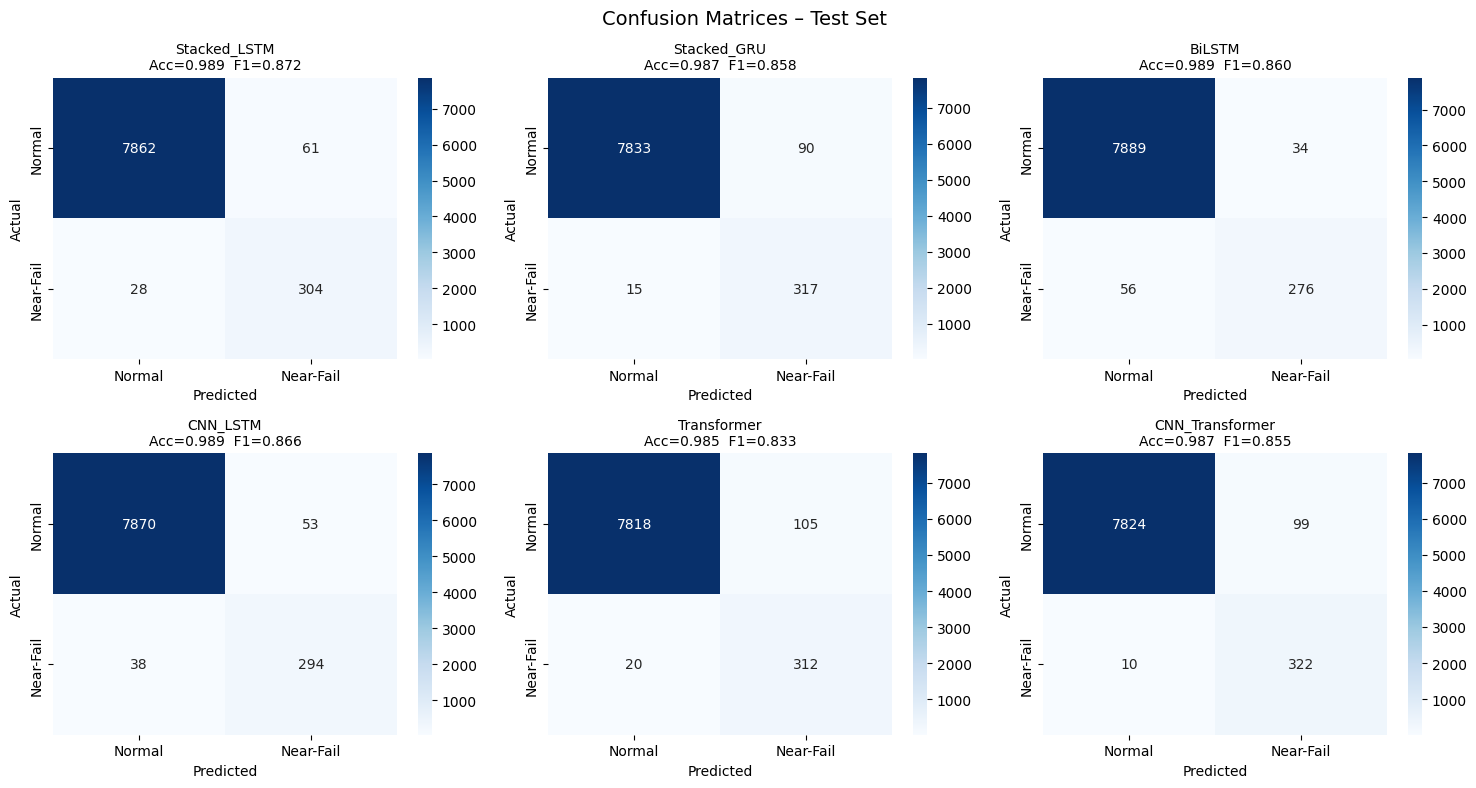

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (name, m) in zip(axes.flat, results.items()):
    sns.heatmap(m['cm'], annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Near-Fail'],
                yticklabels=['Normal', 'Near-Fail'])
    ax.set_title(f'{name}\nAcc={m["accuracy"]:.3f}  F1={m["f1"]:.3f}',
                 fontsize=10)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices – Test Set', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()


## ROC Curves

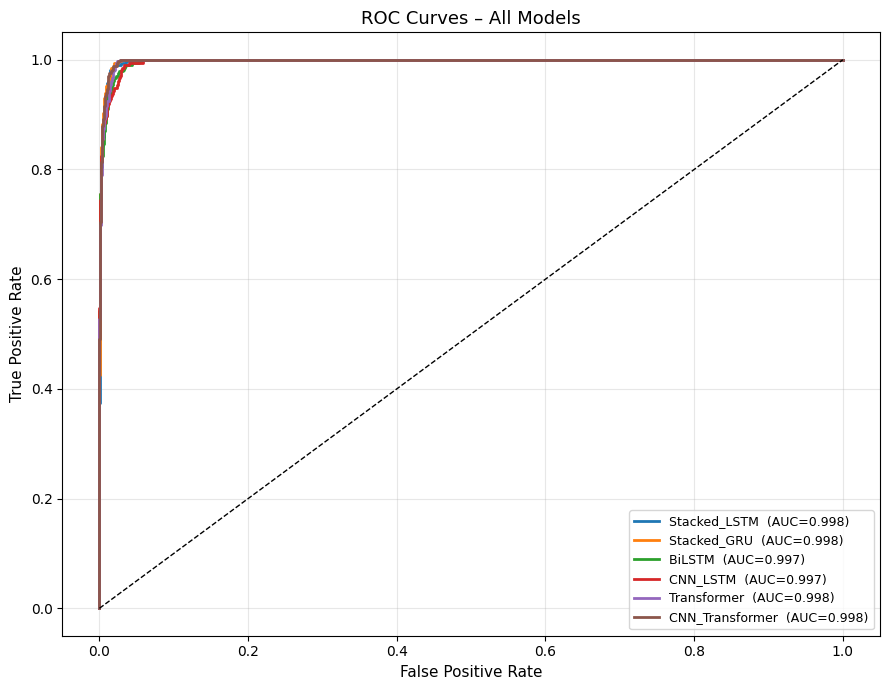

In [19]:
plt.figure(figsize=(9, 7))
colors = plt.cm.tab10.colors
for (name, m), col in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, m['y_prob'])
    plt.plot(fpr, tpr, lw=2, color=col,
             label=f"{name}  (AUC={m['auc']:.3f})")
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate',  fontsize=11)
plt.title('ROC Curves – All Models', fontsize=13)
plt.legend(fontsize=9, loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()


## Metric Bar Chart

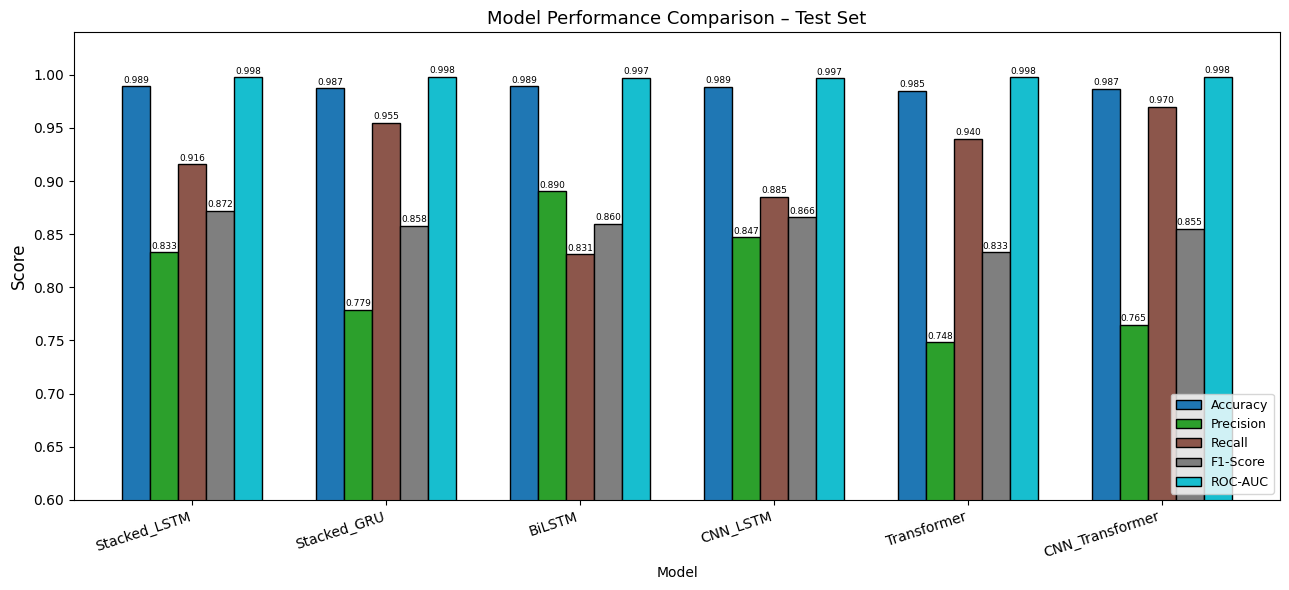

In [20]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
plot_df = summary_df[metrics_to_plot].astype(float)

ax = plot_df.plot(kind='bar', figsize=(13, 6), colormap='tab10',
                  edgecolor='black', width=0.72)
ax.set_ylim(0.6, 1.04)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison – Test Set', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
plt.xticks(rotation=18, ha='right', fontsize=10)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=6.5, padding=1)
plt.tight_layout()
plt.savefig('metric_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


## Threshold Tuning on Best Model

The default 0.5 threshold is rarely optimal.  
We sweep thresholds 0.1 → 0.9 and find the one that maximises F1.


In [21]:
best_name = summary_df['F1-Score'].astype(float).idxmax()
print(f"Best model: {best_name}")

best_model = keras.models.load_model(f'{MODEL_DIR}/{best_name}.keras')
y_prob_best = best_model.predict(X_test, verbose=0).ravel()

thresholds = np.arange(0.10, 0.91, 0.05)
rows = []
for thr in thresholds:
    yp = (y_prob_best >= thr).astype(int)
    rows.append({
        'Threshold' : round(thr, 2),
        'Accuracy'  : round((yp == y_test).mean(), 4),
        'Precision' : round(precision_score(y_test, yp, zero_division=0), 4),
        'Recall'    : round(recall_score(y_test, yp, zero_division=0), 4),
        'F1'        : round(f1_score(y_test, yp, zero_division=0), 4),
    })
thr_df = pd.DataFrame(rows)
print(thr_df.to_string(index=False))

best_thr = thr_df.loc[thr_df['F1'].idxmax(), 'Threshold']
print(f"\nOptimal threshold: {best_thr}")

y_pred_final = (y_prob_best >= best_thr).astype(int)
print("\nFinal Classification Report:")
print(classification_report(y_test, y_pred_final,
                             target_names=['Normal', 'Near-Failure']))


Best model: Stacked_LSTM
 Threshold  Accuracy  Precision  Recall     F1
      0.10    0.9861     0.7553  0.9669 0.8481
      0.15    0.9872     0.7743  0.9608 0.8575
      0.20    0.9876     0.7833  0.9578 0.8618
      0.25    0.9885     0.7970  0.9578 0.8700
      0.30    0.9884     0.7995  0.9488 0.8678
      0.35    0.9880     0.8010  0.9337 0.8623
      0.40    0.9887     0.8153  0.9307 0.8692
      0.45    0.9891     0.8288  0.9187 0.8714
      0.50    0.9892     0.8329  0.9157 0.8723
      0.55    0.9896     0.8475  0.9036 0.8746
      0.60    0.9892     0.8481  0.8916 0.8693
      0.65    0.9893     0.8547  0.8855 0.8698
      0.70    0.9896     0.8639  0.8795 0.8716
      0.75    0.9895     0.8679  0.8705 0.8692
      0.80    0.9893     0.8789  0.8524 0.8654
      0.85    0.9896     0.8917  0.8434 0.8669
      0.90    0.9896     0.8994  0.8343 0.8656

Optimal threshold: 0.55

Final Classification Report:
              precision    recall  f1-score   support

      Normal       

## Per-Engine Prediction Timeline

Engine 1: not enough cycles (31 < 50)
Engine 2: not enough cycles (49 < 50)


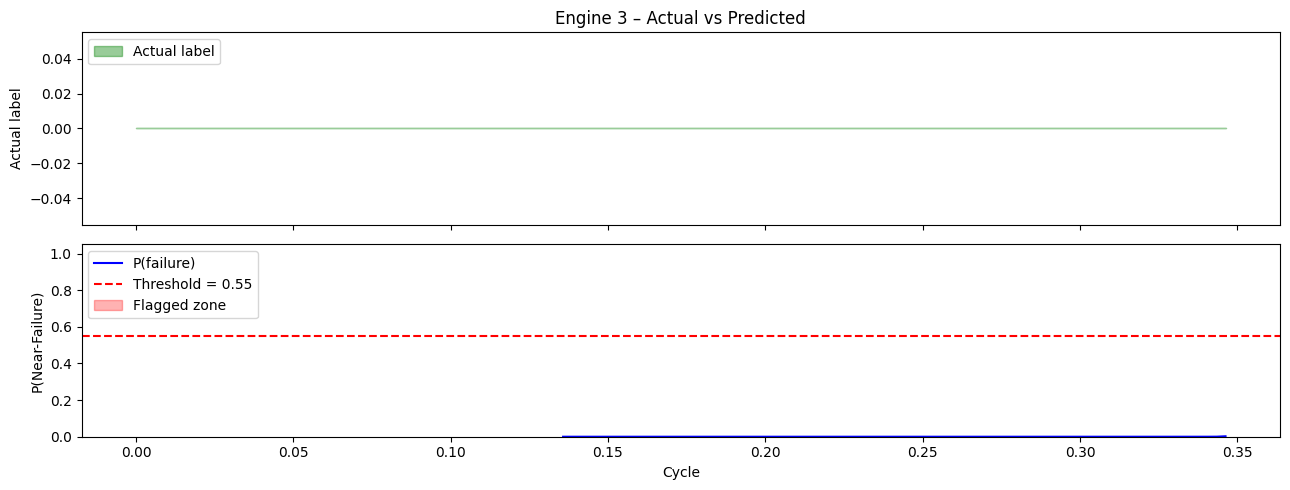

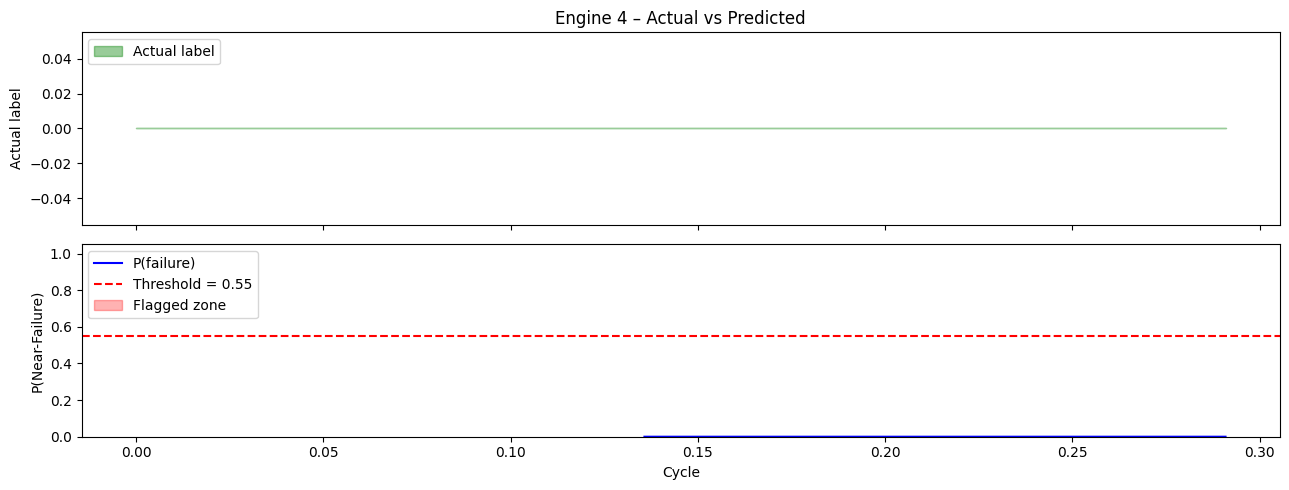

In [22]:
def plot_engine_prediction(engine_id, model, df, feat_cols,
                           seq_len=SEQUENCE_LENGTH, threshold=0.5):
    sub = df[df['id'] == engine_id].sort_values('cycle').reset_index(drop=True)
    if len(sub) < seq_len:
        print(f"Engine {engine_id}: not enough cycles ({len(sub)} < {seq_len})")
        return
    data   = sub[feat_cols].values.astype(np.float32)
    actual = sub['label'].values

    probs = []
    for i in range(len(data) - seq_len + 1):
        x = data[i: i + seq_len][np.newaxis]
        probs.append(model.predict(x, verbose=0)[0, 0])

    cycles_pred = sub['cycle'].values[seq_len - 1:]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 5), sharex=True)
    ax1.fill_between(sub['cycle'], actual, alpha=0.4, color='green', label='Actual label')
    ax1.set_ylabel('Actual label'); ax1.legend(loc='upper left')
    ax1.set_title(f'Engine {engine_id} – Actual vs Predicted')

    ax2.plot(cycles_pred, probs, 'b-', lw=1.5, label='P(failure)')
    ax2.axhline(threshold, color='r', linestyle='--',
                lw=1.5, label=f'Threshold = {threshold}')
    ax2.fill_between(cycles_pred, probs, threshold,
                     where=np.array(probs) >= threshold,
                     alpha=0.3, color='red', label='Flagged zone')
    ax2.set_ylabel('P(Near-Failure)'); ax2.set_xlabel('Cycle')
    ax2.set_ylim(0, 1.05); ax2.legend(loc='upper left')
    plt.tight_layout()
    plt.show()


for eid in test_df['id'].unique()[:4]:
    plot_engine_prediction(eid, best_model, test_df,
                           sequence_cols, threshold=float(best_thr))


## Save Outputs

In [23]:
summary_df.to_csv('model_comparison_results.csv')
print("Saved: model_comparison_results.csv")
print("Saved models are in:", MODEL_DIR)
print("\n  Pipeline completed!")


Saved: model_comparison_results.csv
Saved models are in: saved_models

  Pipeline completed!
